# Hybrid Wind Transformer Notebook


- `helper_function.py`
- `layers.py`
- `training_details.py`
- `hybrid_transformer.py`


# Hybrid Transformer Model for Time Series Prediction

Da model

Put all your possibly correlated time series files into the same directory, with the headers "ws". The time_series_slicer class will pick up the columns with "ws" header. Slice them up into sliding windows with a window size 512.

Then run: `python hybrid_transformer.py --lr LR --batch_size BATCH_SIZE --epochs EPOCHS --decay_rate DECAY_RATE`

Here we picked: `lr = 0.001`, `batch_size = 64`, `epochs = 15`, `decay_rate = -0.001`

## Notes

1. Decay rate here refers to decay rate of the learning rate.
2. A single GPU is mostly enough for any kind of purposes.
3. At the end of training process, the model will be saved automatically.
4. If you'd like to replicate the results in the aforementioned article, download the dataset from the original repository. Training the model for 5 or 6 epochs, you should reach approximately 0.992 R² (average of 7 wind farms) score on the test set.

Update: If you are not a Tensorflow lover, for an updated version of this architecture, please go to:
https://github.com/y-akbal/oneforall


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from time import localtime
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, Dropout, Embedding, Attention,
    Conv1D, Conv2D, Layer, LayerNormalization
)
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger
from tensorflow.keras.optimizers import Adam

# -----------------------------
# User settings
# -----------------------------
DATA_DIR = "/Users/suchitrahallikeri/Downloads/GEF2012-wind-forecasting"   # change if needed
WINDOW_SIZE = 512

LR = 0.001
BATCH_SIZE = 64
EPOCHS = 3
DECAY_RATE = -0.001

print("TensorFlow version:", tf.__version__)
print("Data directory:", DATA_DIR)

TensorFlow version: 2.16.2
Data directory: /Users/suchitrahallikeri/Downloads/GEF2012-wind-forecasting


In [3]:
def write_log(a: str, file="log.txt") -> None:
    lt = list(localtime())
    lc = f"{lt[0]}-{lt[1]}-{lt[2]}---{lt[3]}:{lt[4]}"
    with open(file, mode="a") as my_file:
        my_file.write(f"{lc}:\t{a}\n")


def return_files(data_dir="."):
    """
    Read all CSV files in data_dir and keep only those with a 'ws' column.
    """
    files = []
    data = []
    w_files = []

    print("The following files found:")
    total_len = 0

    for file in os.listdir(data_dir):
        if file.endswith(".csv"):
            full_path = os.path.join(data_dir, file)
            try:
                m = pd.read_csv(full_path)["ws"]
                file_len = len(m)
                total_len += file_len
                files.append(file)
                data.append(m)
                print(f"{file} of length {file_len}")
            except KeyError:
                w_files.append(file)

    print(
        f"The total number of observations is {total_len}, "
        f"there are {len(files)} time series to be processed, "
        f"{len(w_files)} csv files do not have column 'ws'."
    )
    return files, data


class time_series_slices:
    def __init__(self, length=64):
        self.length = length

    def __return_preprocessed_data(self, data__, **kwargs):
        data_ = [data.interpolate(**kwargs) for data in data__]
        data_ = [(data - data.mean()) / (data.std() + 1e-8) for data in data_]

        cls_list = []
        X = []
        y = []

        for j, data in enumerate(data_):
            arr = data.to_numpy()
            for i in range(len(arr) - self.length):
                X.append(arr[i:i + self.length])
                y.append(arr[i + self.length])
                cls_list.append(j)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(cls_list, dtype=np.int32)

    def __split_data(self, data_, alpha):
        lens = [len(data) for data in data_]
        n_len = [int(alpha * n) for n in lens]

        data_train = [data[:n].copy() for n, data in zip(n_len, data_)]
        data_test = [data[n:].copy() for n, data in zip(n_len, data_)]

        for data in data_test:
            data.index = range(len(data))

        return data_train, data_test

    def fit_transform(self, data_, alpha=0.8, **kwargs):
        assert isinstance(data_, list)
        assert all(isinstance(data, pd.Series) for data in data_)

        data_train, data_test = self.__split_data(data_, alpha)
        return (
            self.__return_preprocessed_data(data_train, **kwargs),
            self.__return_preprocessed_data(data_test, **kwargs),
        )


write_log("Helper functions loaded successfully.")

files, data_ = return_files(DATA_DIR)
if len(data_) == 0:
    raise ValueError("No CSV files with a 'ws' column were found in DATA_DIR.")

print("Loaded ws series from:", files)

The following files found:
windforecasts_wf2.csv of length 104832
windforecasts_wf3.csv of length 104832
windforecasts_wf1.csv of length 104832
windforecasts_wf4.csv of length 104832
windforecasts_wf5.csv of length 104832
windforecasts_wf7.csv of length 104832
windforecasts_wf6.csv of length 104832
The total number of observations is 733824, there are 7 time series to be processed, 3 csv files do not have column 'ws'.
Loaded ws series from: ['windforecasts_wf2.csv', 'windforecasts_wf3.csv', 'windforecasts_wf1.csv', 'windforecasts_wf4.csv', 'windforecasts_wf5.csv', 'windforecasts_wf7.csv', 'windforecasts_wf6.csv']


In [17]:
class training_details:
    def __init__(self, lr=0.001, batch_size=64, epochs=15, decay_rate=-0.001):
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.decay_rate = decay_rate

        self.optimizer = Adam(learning_rate=self.lr)
        self.loss = tf.keras.losses.MeanSquaredError()
        self.lr_scheduler_ = LearningRateScheduler(self.lr_scheduler)
        self.csv_logger = CSVLogger("log.csv")
        self.callbacks = [self.lr_scheduler_, self.csv_logger]

    def lr_scheduler(self, epoch, lr):
        if epoch < 3:
            return lr
        return float(lr * tf.math.exp(self.decay_rate))


td = training_details(
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    decay_rate=DECAY_RATE
)

print(vars(td))

{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x17d94b110>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x169dd8d60>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x17cc2e240>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x17cc2e090>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x17cc2e240>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x17cc2e090>]}


## Main training script

This is the original script content converted into a notebook cell. Since notebooks do not use command-line arguments the same way as `.py` scripts, you may later want to replace the `argparse` section with normal Python variables.

In [5]:
class upsample_conv(Layer):
    def __init__(self, pool_size=4, lags=256, internal_dim=128, activation="gelu", use_embed=False):
        super().__init__()
        assert (lags / pool_size).is_integer(), "Lag size should be divisible by pool_size"

        self.conv = Conv1D(
            filters=internal_dim,
            kernel_size=pool_size,
            strides=pool_size,
            use_bias=True
        )
        self.activation = tf.keras.activations.get(activation)
        self.norm = LayerNormalization()
        self.use_embed = use_embed

        if use_embed:
            self.embed = Embedding(int(lags / pool_size), internal_dim)
            self.pos_ids = tf.constant([i for i in range(int(lags / pool_size))], dtype=tf.int32)

    def call(self, inputs, training=None):
        x = self.conv(inputs)
        if self.use_embed:
            x = x + self.embed(self.pos_ids)
        x = self.activation(x)
        x = self.norm(x, training=training)
        return x


class self_attention_heads(Layer):
    def __init__(self, heads=5, causal=False, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.causal = causal
        self.heads = heads
        self.dropout = Dropout(dropout)
        self.conv2d = Conv2D(
            1,
            kernel_size=1,
            strides=1,
            use_bias=True,
            kernel_initializer=tf.keras.initializers.Constant(value=1 / self.heads)
        )

    def build(self, input_shape):
        input_shape = input_shape[0]
        shape = (self.heads, input_shape[-2], input_shape[-2])
        initializer = tf.keras.initializers.Orthogonal()
        initial_value = initializer(shape=shape)
        self.kernel = tf.Variable(initial_value=initial_value, trainable=True)

        if self.causal:
            minf = -tf.constant(20000.0)
            mask = tf.fill(shape, minf)
            self.upper_m = minf - tf.linalg.band_part(mask, num_lower=-1, num_upper=0)

    def call(self, inputs, training=None):
        x1, x2 = inputs[0], inputs[1]

        if training:
            x1 = self.dropout(x1, training=training)
            x2 = self.dropout(x2, training=training)

        x1e = tf.expand_dims(x1, axis=-3)
        x2e = tf.expand_dims(x2, axis=-3)

        sim1 = self.kernel @ x1e
        sim2 = self.kernel @ x2e
        att_scores = tf.matmul(sim1, sim2, transpose_b=True)

        if self.causal:
            att_scores = att_scores + self.upper_m

        softmaxed = tf.nn.softmax(att_scores, axis=-2)
        similarity_heads = softmaxed @ x2e
        transposed = tf.transpose(similarity_heads, [0, 2, 3, 1])
        return tf.squeeze(self.conv2d(transposed), -1)


class upsampling_block(Model):
    def __init__(self, pool_size, lags, internal_dim, attention_heads=5, dropout_rate=0.4, causal=False, **kwargs):
        super().__init__()
        self.upsample_conv = upsample_conv(
            pool_size=pool_size,
            lags=lags,
            internal_dim=internal_dim,
            **kwargs
        )
        self.dropout = Dropout(dropout_rate)
        self.dense = Dense(internal_dim)
        self.att = self_attention_heads(
            heads=attention_heads,
            causal=causal,
            dropout=dropout_rate
        )
        self.layer_norm = LayerNormalization()

    def call(self, inputs, training=None):
        t = self.upsample_conv(inputs, training=training)
        x = self.dropout(t, training=training)
        x = self.dense(x)
        x = self.dropout(x, training=training)
        x = self.att([x, x], training=training) + t
        x = self.layer_norm(x, training=training)
        return x


class upsampling_block_with_embedding(Model):
    def __init__(self, pool_size, lags, internal_dim, dropout_rate=0.4, number_embeedings=8, **kwargs):
        super().__init__()
        self.upsample_conv = upsample_conv(
            pool_size=pool_size,
            lags=lags,
            internal_dim=internal_dim,
            use_embed=True
        )
        self.embedding = Embedding(number_embeedings, internal_dim)
        self.dropout = Dropout(dropout_rate)
        self.dense = Dense(internal_dim)
        self.att = Attention()
        self.layer_norm = LayerNormalization()

    def call(self, inputs, training=None):
        inputs_1, inputs_2 = inputs[0], inputs[1]
        embeddings = self.embedding(inputs_2)
        t = self.upsample_conv(inputs_1, training=training)
        x = self.dropout(t, training=training)
        x = self.dense(x) + tf.expand_dims(embeddings, 1)
        x = self.att([x, x], training=training) + t
        x = self.layer_norm(x, training=training)
        return x


print("Custom layers loaded successfully.")

Custom layers loaded successfully.


In [7]:
print("Splitting the above series...")
slicer = time_series_slices(WINDOW_SIZE)
train, test = slicer.fit_transform(data_)

X_train, y_train, train_class = train
X_test, y_test, test_class = test

# Conv1D expects: (batch, steps, channels)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Splitting into test and train sets is done!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train_class shape:", train_class.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("test_class shape:", test_class.shape)

write_log("Data split and reshaping completed.")

Splitting the above series...
Splitting into test and train sets is done!
X_train shape: (583471, 512, 1)
y_train shape: (583471,)
train_class shape: (583471,)
X_test shape: (143185, 512, 1)
y_test shape: (143185,)
test_class shape: (143185,)


In [25]:
class main_model(Model):
    def __init__(
        self,
        pool_sizes=[8, 4, 2, 1, 1],
        lags=512,
        internal_dims=[128, 256, 256, 256, 256],
        recurent_head_dim=128,
        num_series=7
    ):
        super().__init__()
        assert len(internal_dims) == len(pool_sizes), "Set the internal dims and pool sizes properly"

        self.pool_sizes = pool_sizes
        self.initial_lag = lags
        self.internal_dims = internal_dims
        self._lags = []
        self.set_lags()

        self.lstm = LSTM(recurent_head_dim)
        self.dense = Dense(1)
        self.recurrent_head = Sequential([self.lstm, self.dense])

        self.first_layer = upsampling_block_with_embedding(
            pool_size=pool_sizes[0],
            lags=lags,
            internal_dim=internal_dims[0],
            number_embeedings=num_series
        )

        self.rest = Sequential([
            upsampling_block(i, int(j), k)
            for i, j, k in zip(self.pool_sizes[1:], self._lags[1:], self.internal_dims[1:])
        ])

    def set_lags(self):
        self._lags.append(self.initial_lag)
        for i in self.pool_sizes:
            lag = self._lags[-1] / i
            if lag.is_integer():
                self._lags.append(lag)
            else:
                raise ValueError("Pool sizes do not divide lag sizes cleanly.")

    def fit_(self, training_details_obj):
        print(vars(training_details_obj))

        self.compile(
            loss=training_details_obj.loss,
            optimizer=training_details_obj.optimizer,
            jit_compile=False
        )

        history = self.fit(
            [X_train, train_class],
            y_train,
            batch_size=training_details_obj.batch_size,
            epochs=training_details_obj.epochs,
            validation_data=([X_test, test_class], y_test),
            callbacks=training_details_obj.callbacks,
            verbose=1
        )
        return history

    def call(self, inputs, training=None):
        x = self.first_layer(inputs, training=training)
        x = self.rest(x, training=training)
        x = self.recurrent_head(x)
        return x


print("Main model class loaded successfully.")

Main model class loaded successfully.


In [29]:
write_log("Training started")
print("Building model...")

model = main_model(
    pool_sizes=[8, 4, 2, 1, 1],
    lags=WINDOW_SIZE,
    internal_dims=[128, 256, 256, 256, 256],
    recurent_head_dim=128,
    num_series=len(files)
)

write_log("Model initiated")
print("Starting training...")

history = model.fit_(td)

write_log("Training ended")
print("Training complete")

model.save("hybrid_wind_fixed.keras")
print("Model saved as hybrid_wind_fixed.keras")

Building model...
Starting training...
{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x305689ca0>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x17ff50cc0>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x30767d940>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x30767da60>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x30767d940>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x30767da60>]}
Epoch 1/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 1806s 197ms/step - loss: 0.0566 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 2/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 1799s 197ms/step - loss: 0.0317 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 3/3
9117/9117 ━━━━━━━━━━━━━━━━━━━━ 1788s 196ms/step - loss: 0.0275 - val_loss: 0.0259 - learning_rate: 0.0010
Training complete
Model saved

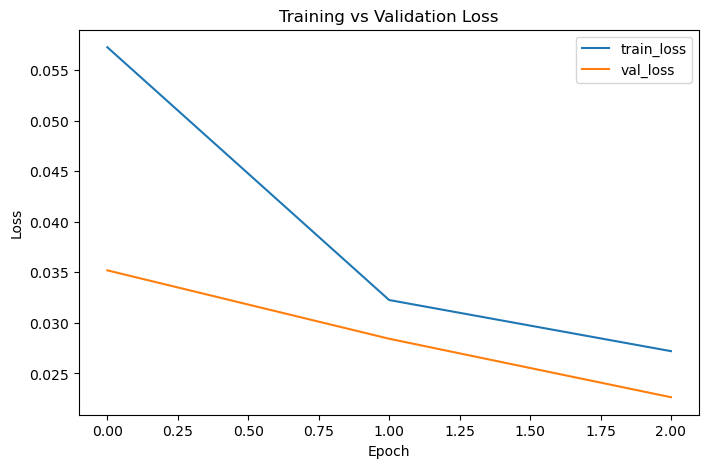

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [12]:
model.save("hybrid_wind_fixed.keras")

In [13]:
y_pred = model.predict([X_test, test_class], batch_size=BATCH_SIZE)
y_pred = y_pred.squeeze()

2238/2238 ━━━━━━━━━━━━━━━━━━━━ 115s 51ms/step


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.02264847
MAE: 0.064096466
R2: 0.9775907426011032


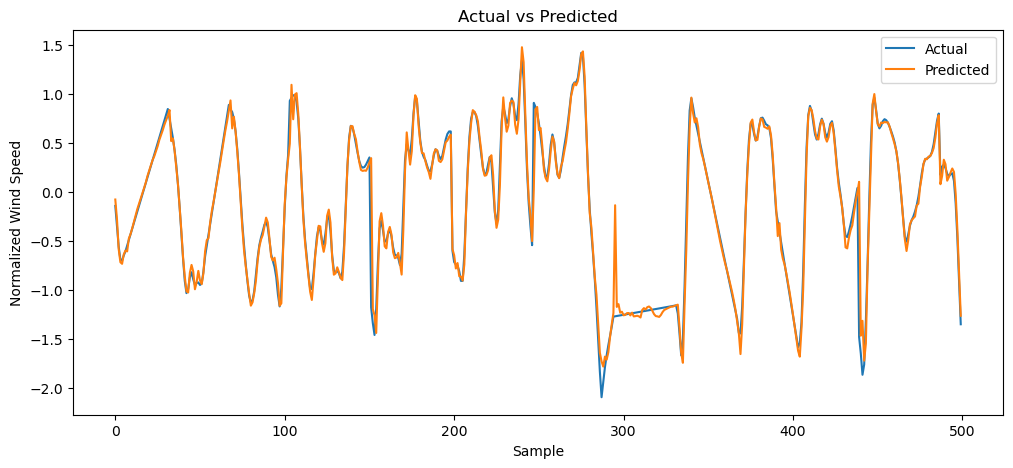

In [15]:
plt.figure(figsize=(12,5))
plt.plot(y_test[:500], label='Actual')
plt.plot(y_pred[:500], label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Sample')
plt.ylabel('Normalized Wind Speed')
plt.legend()
plt.show()

In [16]:
window_sizes = [64, 128, 256, 512]
window_results = []

for ws in window_sizes:
    print(f"\n--- Testing WINDOW_SIZE = {ws} ---")

    # re-slice data with new window size
    slicer = time_series_slices(ws)
    train, test = slicer.fit_transform(data_)

    X_train, y_train, train_class = train
    X_test, y_test, test_class = test

    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    # build fresh model
    model = main_model(
        pool_sizes=[8, 4, 2, 1, 1],
        lags=ws,
        internal_dims=[128, 256, 256, 256, 256],
        recurent_head_dim=128,
        num_series=len(files)
    )

    td = training_details(
        lr=LR,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        decay_rate=DECAY_RATE
    )

    history = model.fit_(td)

    y_pred = model.predict([X_test, test_class], batch_size=BATCH_SIZE).squeeze()

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    window_results.append({
        "window_size": ws,
        "mse": mse,
        "mae": mae,
        "r2": r2,
        "final_val_loss": history.history["val_loss"][-1]
    })

window_results_df = pd.DataFrame(window_results).sort_values("mse")
print(window_results_df)


--- Testing WINDOW_SIZE = 64 ---
{'lr': 0.001, 'batch_size': 64, 'epochs': 3, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x16afec650>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x1559ade40>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x16a5a5ac0>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x16a5a5be0>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x16a5a5ac0>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x16a5a5be0>]}
Epoch 1/3
9166/9166 ━━━━━━━━━━━━━━━━━━━━ 386s 41ms/step - loss: 0.0522 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 2/3
9166/9166 ━━━━━━━━━━━━━━━━━━━━ 351s 38ms/step - loss: 0.0333 - val_loss: 0.0262 - learning_rate: 0.0010
Epoch 3/3
9166/9166 ━━━━━━━━━━━━━━━━━━━━ 397s 43ms/step - loss: 0.0266 - val_loss: 0.0228 - learning_rate: 0.0010
2287/2287 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/

In [27]:
from itertools import product
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_and_evaluate_hybrid(data_, window_size, batch_size, epochs, lr):
    global X_train, y_train, train_class, X_test, y_test, test_class

    # Re-slice data for the given window size
    slicer = time_series_slices(window_size)
    train, test = slicer.fit_transform(data_)

    X_train, y_train, train_class = train
    X_test, y_test, test_class = test

    # Add channel dimension for Conv1D
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    # Build fresh model
    model = main_model(
        pool_sizes=[8, 4, 2, 1, 1],
        lags=window_size,
        internal_dims=[128, 256, 256, 256, 256],
        recurent_head_dim=128,   
        num_series=len(files)
    )

    # Training config
    td = training_details(
        lr=lr,
        batch_size=batch_size,
        epochs=epochs,
        decay_rate=DECAY_RATE
    )

    # Train
    history = model.fit_(td)

    # Hybrid model predictions
    y_pred_hybrid = model.predict([X_test, test_class], batch_size=batch_size).squeeze()

    # Persistence baseline: predict next value as last value in input window
    y_pred_baseline = X_test[:, -1, 0]

    # Metrics
    hybrid_mse = mean_squared_error(y_test, y_pred_hybrid)
    hybrid_mae = mean_absolute_error(y_test, y_pred_hybrid)
    hybrid_r2 = r2_score(y_test, y_pred_hybrid)

    baseline_mse = mean_squared_error(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_r2 = r2_score(y_test, y_pred_baseline)

    result = {
        "window_size": window_size,
        "batch_size": batch_size,
        "epochs": epochs,
        "lr": lr,
        "hybrid_mse": hybrid_mse,
        "hybrid_mae": hybrid_mae,
        "hybrid_r2": hybrid_r2,
        "baseline_mse": baseline_mse,
        "baseline_mae": baseline_mae,
        "baseline_r2": baseline_r2,
        "final_val_loss": history.history["val_loss"][-1]
    }

    artifacts = {
        "model": model,
        "history": history,
        "y_test": y_test,
        "y_pred_hybrid": y_pred_hybrid,
        "y_pred_baseline": y_pred_baseline
    }

    return result, artifacts

In [23]:
# Step 2: Tune batch size and epochs
batch_epoch_results = []

for bs, ep in product([64], [2]):
    print(f"\nRunning batch_size = {bs}, epochs = {ep}")

    result, _ = train_and_evaluate_hybrid(
        data_=data_,
        window_size=128,   
        epochs=ep,
        lr=0.001
    )

    batch_epoch_results.append(result)

batch_epoch_results_df = (
    pd.DataFrame(batch_epoch_results)
    .sort_values("hybrid_mse")
    .reset_index(drop=True)
)

print(batch_epoch_results_df)


Running batch_size = 64, epochs = 2
{'lr': 0.001, 'batch_size': 64, 'epochs': 2, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x30941b170>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x30793b9c0>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x30941b500>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x30941b5f0>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x30941b500>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x30941b5f0>]}
Epoch 1/2
9159/9159 ━━━━━━━━━━━━━━━━━━━━ 715s 77ms/step - loss: 0.0538 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 2/2
9159/9159 ━━━━━━━━━━━━━━━━━━━━ 748s 82ms/step - loss: 0.0316 - val_loss: 0.0249 - learning_rate: 0.0010
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 47s 20ms/step
   window_size  batch_size  epochs     lr  hybrid_mse  hybrid_mae  hybrid_r2  \
0          128          64

In [25]:
# Step 3: Change learning rate
lr_results = []

for lr in [1e-4, 5e-4, 1e-3, 5e-3]:
    print(f"\nRunning learning rate = {lr}")

    result, _ = train_and_evaluate_hybrid(
        data_=data_,
        window_size=64,   # use best window size
        batch_size=64,     # use best batch size
        epochs=1,         # use best epoch count
        lr=lr
    )

    lr_results.append(result)

lr_results_df = (
    pd.DataFrame(lr_results)
    .sort_values("hybrid_mse")
    .reset_index(drop=True)
)

print(lr_results_df)


Running learning rate = 0.0001
{'lr': 0.0001, 'batch_size': 64, 'epochs': 1, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x14e541910>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x301becd60>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x14e541c40>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x14e541cd0>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x14e541c40>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x14e541cd0>]}
9166/9166 ━━━━━━━━━━━━━━━━━━━━ 417s 45ms/step - loss: 0.0879 - val_loss: 0.0359 - learning_rate: 1.0000e-04
2287/2287 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step

Running learning rate = 0.0005
{'lr': 0.0005, 'batch_size': 64, 'epochs': 1, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x153438ec0>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0

In [29]:
# Step 4: Compare against persistence forecast baseline
best_result, best_artifacts = train_and_evaluate_hybrid(
    data_=data_,
    window_size=64,   
    batch_size=64,    
    epochs=1,        
    lr=0.001           
)

print("Best run comparison:")
print(pd.DataFrame([best_result]))

{'lr': 0.001, 'batch_size': 64, 'epochs': 1, 'decay_rate': -0.001, 'optimizer': <keras.src.optimizers.adam.Adam object at 0x17d9bdf70>, 'loss': <LossFunctionWrapper(<function mean_squared_error at 0x169dd8d60>, kwargs={})>, 'lr_scheduler_': <keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x17d9be9c0>, 'csv_logger': <keras.src.callbacks.csv_logger.CSVLogger object at 0x17d9be990>, 'callbacks': [<keras.src.callbacks.learning_rate_scheduler.LearningRateScheduler object at 0x17d9be9c0>, <keras.src.callbacks.csv_logger.CSVLogger object at 0x17d9be990>]}
9166/9166 ━━━━━━━━━━━━━━━━━━━━ 415s 45ms/step - loss: 0.0523 - val_loss: 0.0387 - learning_rate: 0.0010
2287/2287 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Best run comparison:
   window_size  batch_size  epochs     lr  hybrid_mse  hybrid_mae  hybrid_r2  \
0           64          64       1  0.001    0.038657    0.116925   0.961375   

   baseline_mse  baseline_mae  baseline_r2  final_val_loss  
0      0.057376      0.13

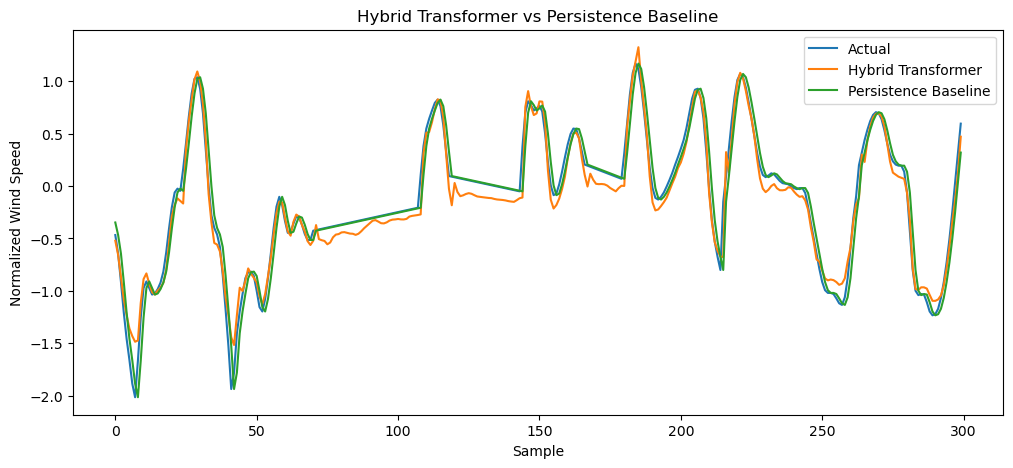

In [32]:
# Plot hybrid vs baseline vs actual
def plot_best_vs_baseline(artifacts, n_points=300):
    y_test = artifacts["y_test"]
    y_pred_hybrid = artifacts["y_pred_hybrid"]
    y_pred_baseline = artifacts["y_pred_baseline"]

    plt.figure(figsize=(12, 5))
    plt.plot(y_test[:n_points], label="Actual")
    plt.plot(y_pred_hybrid[:n_points], label="Hybrid Transformer")
    plt.plot(y_pred_baseline[:n_points], label="Persistence Baseline")
    plt.title("Hybrid Transformer vs Persistence Baseline")
    plt.xlabel("Sample")
    plt.ylabel("Normalized Wind Speed")
    plt.legend()
    plt.show()

plot_best_vs_baseline(best_artifacts, n_points=300)